# The Beginning

Hopefully I will be using this file to create a script to find the carrier concentration of a specific metal and eventually implement a doping mechanic. I don't know what these mean yet, but I should be the end!

In [6]:
import numpy as np
from scipy.integrate import quad
import physics_tools as pt
import matplotlib.pyplot as plt
"""
# Fundamental Constants
k_B = 1.3806e-23 # Boltzmann
h = 6.6261e-34 # Planck Constant
h_bar = h/ (2 * np.pi) # Reduced Planck

m_e = 9.109e-31 # electron mass
q = 1.602e-19 # electron charge

# Silicon constants for testing
m_n_eff = 1.08 * m_e # effective mass of carrier
E_gap = 1.12 * q # Bandgap energy
E_Fermi = 0.56 * q # Fermi level
m_p_eff = 0.81 * m_e # effective mass for hole
"""
# --- 1. Constants (Strictly SI) ---
q = 1.60218e-19
k_B = 1.38065e-23
h_bar = 1.05457e-34
m_e = 9.109e-31
m_n_eff = 1.18 * m_e
m_p_eff = 0.81 * m_e

E_c_j = 1.12 * q      # Conduction band in Joules
E_f_j = 0.56 * q      # Mid-gap Fermi level in Joules
E_v_j = 0


In [7]:
#def fermi_dirac_dist(E, E_F, T):      #
#    exponent = (E - E_F) / (k_B * T)  # Fermi-Dirac distribution
#    return 1 / (1 + np.exp(exponent)) #
def fermi_dirac_dist(E, Ef, T):
    exponent = (E - Ef) / (k_B * T)
    exponent = np.clip(exponent, -700, 700)
    return 1 / (1 + np.exp(exponent))

def density_states_cband(E, Ec):    #
    # Outputs states/m^3/J
    prefactor = (1 / (2 * np.pi**2)) * (2 * m_n_eff / h_bar**2)**1.5
    return prefactor * np.sqrt(np.maximum(0, E - Ec))

#def density_states_vband(E,E_v = 0):
#    prefactor = (1 / (2 * np.pi**2)) * (2 * m_p_eff / h_bar**2)**1.5
#    #g = np.where(E>=E_c, prefactor * np.sqrt(E-E_c), 0)
#    dE = (E_v - E) * q
#    g = prefactor * np.sqrt(np.maximum(dE,0))
#   # g = np.where(dE >= 0, g, 0)
#    return g*q

def density_states_vband(E_j, E_v_j=0):
    # Prefactor stays in SI (m^-3 J^-1.5)
    prefactor = (1 / (2 * np.pi**2)) * (2 * m_p_eff / h_bar**2)**1.5

    # Convert dE to Joules ONLY for the prefactor calculation
    dE_j = (E_v_j - E_j)

    g_j = prefactor * np.sqrt(np.maximum(0,dE_j))

    # Return g in (states / m^3 / eV) so the integral over dE(eV) is correct
    return g_j

def carrier_integrand(E, Ec, Ef, T):                                  #
    return density_states_cband(E, Ec) * fermi_dirac_dist(E, Ef, T) # Fermi-Dirac integral

def hole_integrand(E,E_F,T,E_v = 0):
    return density_states_vband(E, E_v) * fermi_dirac_dist(E_F, E, T)

In [8]:
# Testing Parameters
Temp = 300
E_valence_ev = 0

n_true, error = quad(carrier_integrand, E_c_j, E_c_j + (15 * k_B * Temp),args=(E_c_j, E_f_j, Temp))
n = pt.simpson_vector(carrier_integrand, E_c_j, E_c_j + (15 * k_B * Temp), 1000, E_c_j, E_f_j, Temp)
p = pt.simpson_vector(hole_integrand, E_valence_ev - (15 * k_B * Temp), E_valence_ev, 1000, E_f_j, Temp,E_v_j)
err = np.abs((n - n_true)/n_true)*100
print(f"Carrier concentration (n) at {Temp}K: {n} m^-3")
print(f"Carrier concentration (n_true) at {Temp}K: {n_true} m^-3")
print(f"Error for n against n_true: {err}%")
print(f"Hole concentration (p) at {Temp}K: {p:e} m^-3")

Carrier concentration (n) at 300K: 1.258048877689877e+16 m^-3
Carrier concentration (n_true) at 300K: 1.2582611911081388e+16 m^-3
Error for n against n_true: 0.016873556918243465%
Hole concentration (p) at 300K: 7.154875e+15 m^-3


$$f(E)=\frac{1}{1+e^{\frac{E-E_F}{k_BT}}}$$This is the Fermi-Dirac Distribution function $$g_c(E) = \frac{1}{2\pi^2} \left(\frac{2m_c^*}{\hbar^2}\right)^{3/2}\sqrt{E-E_c}$$This is the Density of States function for the Conduction band.$$g_v(E) = \frac{1}{2\pi^2} \left(\frac{2m_h^*}{\hbar^2}\right)^{3/2}\sqrt{E_v-E}$$This is the Density of States function for the Valence band.

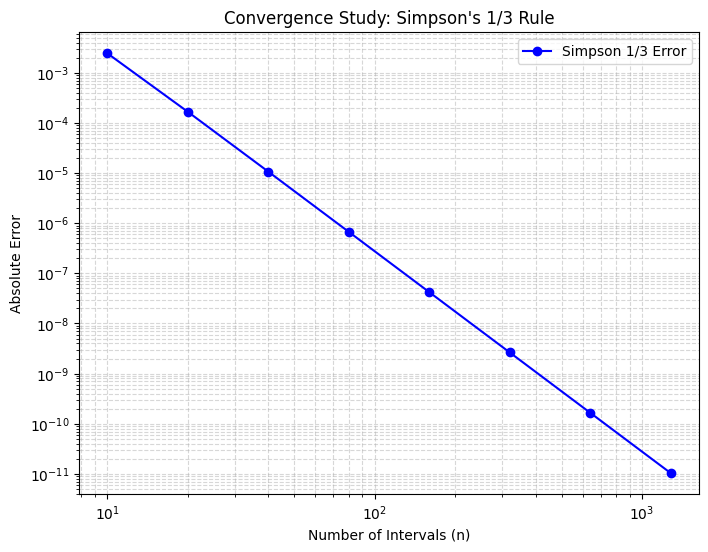

In [9]:

# 1. Define a "Physics-like" test function
def test_func(x, decay_rate):
    return np.exp(-decay_rate * x)

# 2. Define the exact analytical answer so we can calculate the error
# Integral of e^(-2x) from 0 to 5 is: (1/2) * (1 - e^(-10))
decay_rate = 2
a, b = 0, 5
exact_area = (1 / decay_rate) * (1 - np.exp(-decay_rate * b))

# 3. Create an array of n values to test (MUST be even numbers!)
n_values = np.array([10, 20, 40, 80, 160, 320, 640, 1280])
errors = []

# 4. Run the simulation for each step size
for n in n_values:
    # Remember to pass your 'decay_rate' *args at the end!
    sim_area = pt.simpson_vector(test_func, a, b, n, decay_rate)

    # Calculate Absolute Error
    err = abs(exact_area - sim_area)
    errors.append(err)

# 5. Plotting the Error
plt.figure(figsize=(8, 6))
plt.loglog(n_values, errors, marker='o', linestyle='-', color='blue', label='Simpson 1/3 Error')

# Formatting for a professional look
plt.xlabel('Number of Intervals (n)')
plt.ylabel('Absolute Error')
plt.title('Convergence Study: Simpson\'s 1/3 Rule')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

The %error between my custom simpson_vector function and SciPy's quad function at 1000 iterations is roughly 0.01% meaning it should be currently able to be used in "production"

In [10]:


def safe_fermi_dirac(E, Ef, T):
    # Prevent Division by Zero if T is exactly 0
    if T <= 0:
        return np.where(E < Ef, 1.0, 0.0)

    exponent = (E - Ef) / (k_B * T)

    # If the exponent is huge (e.g., > 700), the probability is 0
    # If the exponent is very small (e.g., < -700), the probability is 1
    return np.where(exponent > 700, 0.0,
           np.where(exponent < -700, 1.0,
           1 / (1 + np.exp(exponent))))



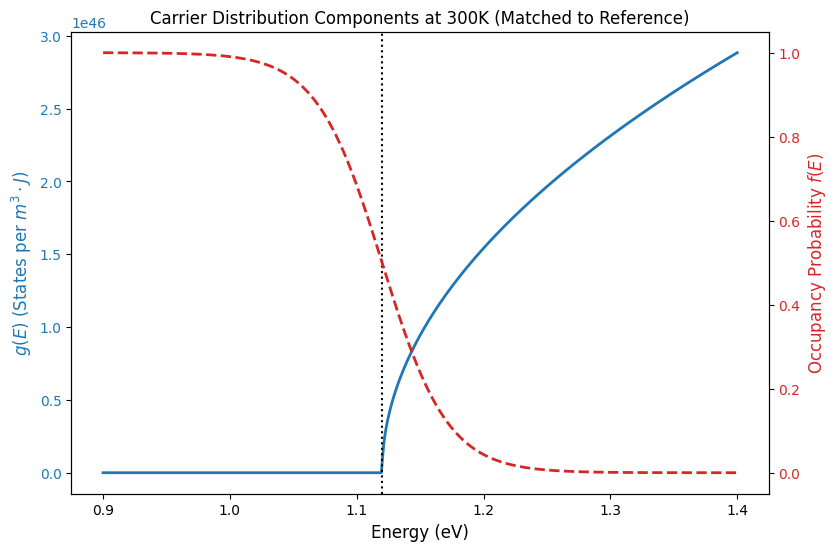

In [11]:
E_c_ev = 1.12

# --- 3. Generate Data ---
# Range: 0.9 eV to 1.4 eV to match your image
E_j_array = np.linspace(0.9 * q, 1.4 * q, 500)
y_dos = density_states_cband(E_j_array, E_c_j)
y_prob = fermi_dirac_dist(E_j_array, E_c_j, 300)

# --- 4. Plotting ---
fig, ax1 = plt.subplots(figsize=(9, 6))

# Blue Axis (DOS)
ax1.plot(E_j_array/q, y_dos, color='tab:blue', lw=2, label='$g(E)$')
ax1.set_ylabel(r'$g(E)$ (States per $m^3 \cdot J$)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Red Axis (Probability)
ax2 = ax1.twinx()
ax2.plot(E_j_array/q, y_prob, color='tab:red', ls='--', lw=2, label='$f(E)$')
ax2.set_ylabel('Occupancy Probability $f(E)$', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Formatting
ax1.axvline(E_c_ev, color='black', ls=':')
ax1.set_xlabel('Energy (eV)', fontsize=12)
plt.title('Carrier Distribution Components at 300K (Matched to Reference)')
plt.show()

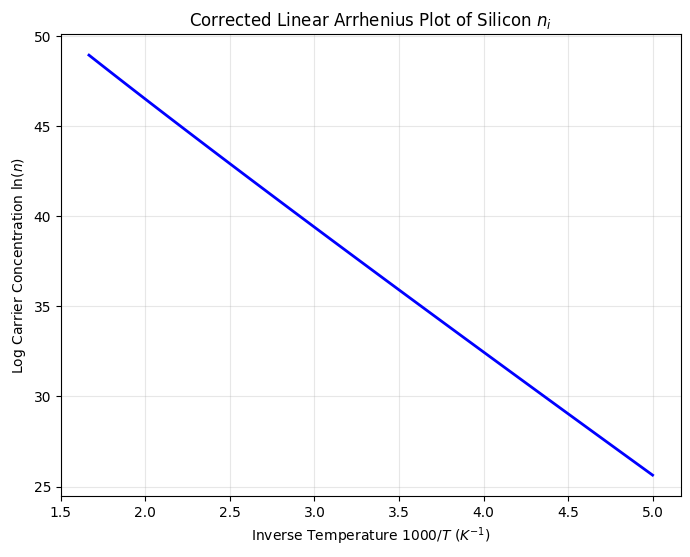

In [12]:
T_range = np.linspace(200, 600, 50)
n_values = []

for Temp in T_range:
    # Use 15*kT range to capture the full tail
    upper = E_c_j + (15 * k_B * Temp)
    val = pt.simpson_vector(carrier_integrand, E_c_j, upper, 1000, E_c_j, E_f_j, Temp)
    n_values.append(val)

# --- 4. The Linear Arrhenius Plot ---
inv_T_scaled = 1000 / T_range  # Professional 1000/T scaling

plt.figure(figsize=(8, 6))
plt.plot(inv_T_scaled, np.log(n_values), 'b-', lw=2, label='Calculated $n_i$')

# Professional Labeling
plt.xlabel(r'Inverse Temperature $1000/T$ ($K^{-1}$)')
plt.ylabel(r'Log Carrier Concentration $\ln(n)$')
plt.title('Corrected Linear Arrhenius Plot of Silicon $n_i$')
plt.grid(True, alpha=0.3)
plt.show()


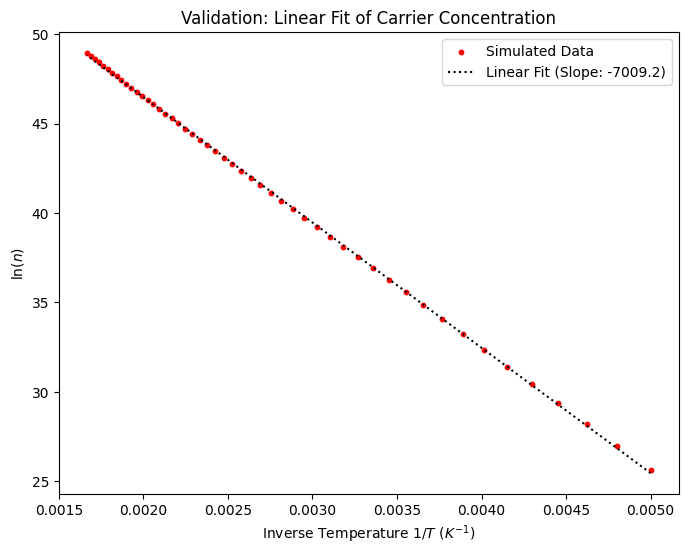

Linear Fit: y = -7009.18x + 60.50


In [13]:
# 1. Get the slope and intercept
m, b = np.polyfit(1/T_range, np.log(n_values), 1)

# 2. Create the "Fit" line
fit_line = m * (1/T_range) + b

# 3. Plot both
plt.figure(figsize=(8, 6))
plt.scatter(1/T_range, np.log(n_values), label='Simulated Data', color='red', s=10)
plt.plot(1/T_range, fit_line, label=f'Linear Fit (Slope: {m:.1f})', color='black', linestyle=':')

plt.xlabel(r'Inverse Temperature $1/T$ ($K^{-1}$)')
plt.ylabel(r'$\ln(n)$')
plt.legend()
plt.title('Validation: Linear Fit of Carrier Concentration')
plt.show()

print(f'Linear Fit: y = {m:.2f}x + {b:.2f}')

Now that we have the slope $m = -7009.18$ eV, we can find the "real" Silicon bandgap with $$m=-\frac{E_g}{2K_B}$$ this simplifies to $$E_g = m\cdot (-2\cdot k_B)$$ using the eV Boltzmann constant ($k_B = 8.617\times 10^{-5}$) $$E_g = -7009.18\cdot(-2\cdot 8.617\times 10^{-5}) \approx 1.208 \text{ eV}$$This fits the widely accepted value of the effective bandgap $E_{eff} = 1.21$ eV

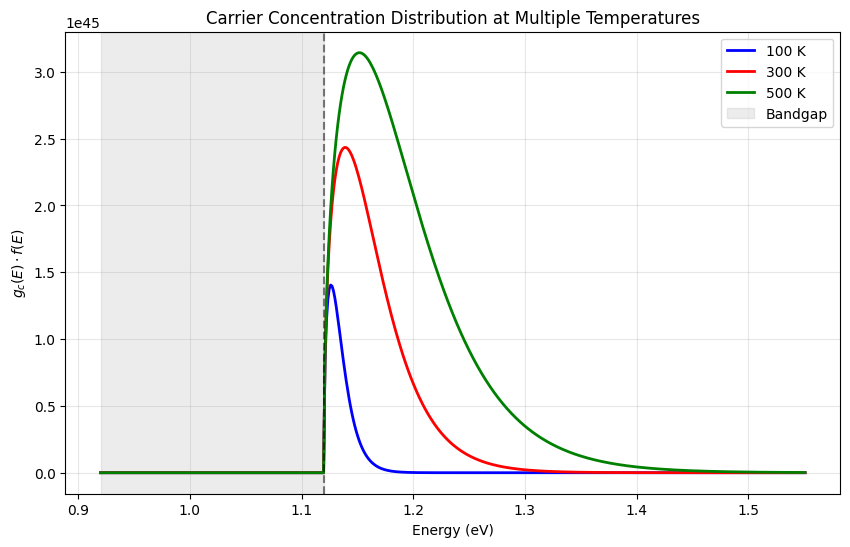

In [14]:
E_unified = np.linspace(E_c_j -(.2* q) ,E_c_j + (10 * k_B * 500), 500)

y_100 = safe_fermi_dirac(E_unified, E_c_j, 100)*density_states_cband(E_unified, E_c_j)
y_300 = safe_fermi_dirac(E_unified, E_c_j, 300)*density_states_cband(E_unified, E_c_j)
y_500 = safe_fermi_dirac(E_unified, E_c_j, 500)*density_states_cband(E_unified, E_c_j)

plt.figure(figsize=(10, 6))

plt.plot(E_unified/q, y_100, label='100 K', color='blue', lw=2)
plt.plot(E_unified/q, y_300, label='300 K', color='red', lw=2)
plt.plot(E_unified/q, y_500, label='500 K', color='green', lw=2)

plt.axvspan(E_unified[0]/q, E_c_j/q, color='gray', alpha=0.15, label='Bandgap')
plt.axvline(E_c_j/q, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Energy (eV)')
plt.ylabel(r'$g_c(E) \cdot f(E)$')
plt.title('Carrier Concentration Distribution at Multiple Temperatures')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

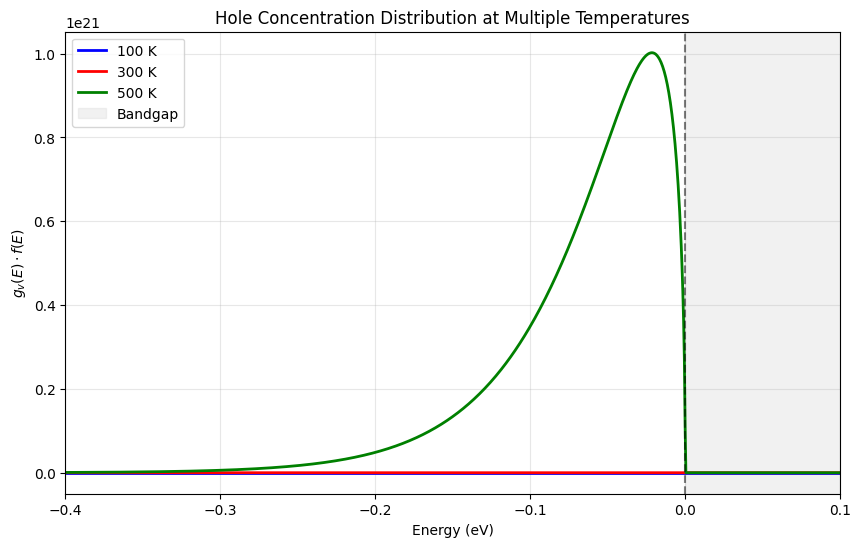

In [15]:
E_ev_array = np.linspace(-0.4, 0.1, 1000)
E_j_array = E_ev_array * q  # Convert to Joules for the engine

temps = [100, 300, 500]
colors = ['blue', 'red', 'green']

plt.figure(figsize=(10, 6))

for T, color in zip(temps, colors):
    # 1. DOS Calculation (SI)
    dos_j = density_states_vband(E_j_array, E_v_j)

    # 2. Hole Probability Calculation
    # By swapping Ef_j and E_j_array, we mathematically calculate 1 - f_e(E)
    # This prevents the computer from rounding errors deep in the band!
    hole_prob = fermi_dirac_dist(E_f_j, E_j_array, T)

    # 3. Calculate Distribution: g(E) * f_h(E)
    # Output is in States per m^3 per Joule
    dist_j = dos_j * hole_prob

    # Convert Y-axis back to eV scale for the plot (multiply by q)
    plt.plot(E_ev_array, dist_j * q, color=color, label=f'{T} K', lw=2)

# --- 4. Professional Formatting ---
# Shade the bandgap starting at 0 eV and going up
plt.axvspan(0, 0.1, color='lightgray', alpha=0.3, label='Bandgap')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

plt.title('Hole Concentration Distribution at Multiple Temperatures')
plt.xlabel('Energy (eV)')
plt.ylabel(r'$g_v(E) \cdot f(E)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-0.4, 0.1)
plt.show()

Both distributions accurately reflect how temperature affects both hole and carrier concentration. Because temperature and energy are the same at quantum scale as the temperature increases the hole concentration greatly increases as the electron can move much easier.

In [27]:
import importlib
importlib.reload(pt)

def charge_neutrality_objective(E_f_guess_j, Temp,N_A, N_D):
    n = pt.simpson_vector(carrier_integrand, E_c_j, E_c_j + (15 * k_B * Temp), 1000, E_c_j, E_f_guess_j, Temp)

    p = pt.simpson_vector(hole_integrand, E_v_j - (15 * k_B * Temp), E_v_j, 1000, E_f_guess_j, Temp, E_v_j)

    net_charge = p - n + N_D - N_A

    return net_charge

N_D = 1e22
N_A = 0.0
Temp = 300
bound_lower_j = 0.0           # Valence Band
bound_upper_j = E_c_j         # Conduction Band (1.12 * q)
initial_guess_j = 0.81*q

Ef_solution_j = pt.bisection_method(charge_neutrality_objective, bound_lower_j, bound_upper_j , Temp, N_A, N_D)


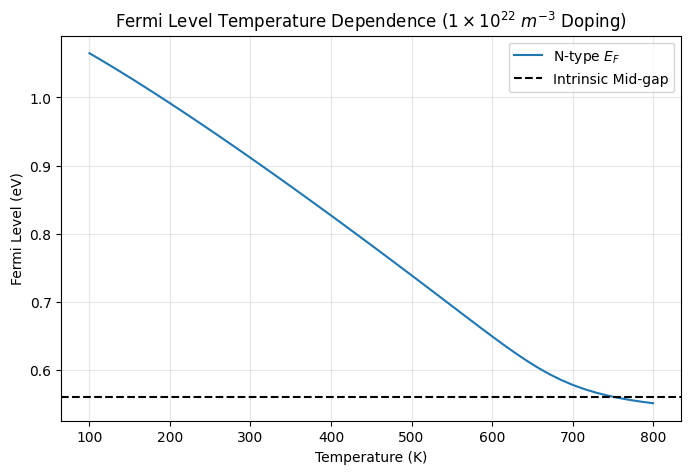

In [17]:
T_sweep = np.linspace(100, 800, 50)
Ef_results = []

for T in T_sweep:
    # We use the previous solution as a hint or just keep the bounds wide
    sol = pt.bisection_method(charge_neutrality_objective, 0, E_c_j, T, N_A, N_D)
    Ef_results.append(sol / q)

plt.figure(figsize=(8, 5))
plt.plot(T_sweep, Ef_results, label='N-type $E_F$')
plt.axhline(0.56, color='black', linestyle='--', label='Intrinsic Mid-gap')
plt.xlabel('Temperature (K)')
plt.ylabel('Fermi Level (eV)')
plt.title(r'Fermi Level Temperature Dependence ($1\times 10^{22}$ $m^{-3}$ Doping)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import physics_tools as pt
from materials import Silicon, GalliumArsenide, q, k_B

# 1. Define the simulation space
Temp = 300 # K
N_D = 1e22 # m^-3
N_A = 0.0

# 2. Select the material
material = Silicon

# 3. Ask the material for its properties at this specific temperature
E_v_j = 0.0 # Reference level
E_c_j = material.get_bandgap_j(Temp)
N_c = material.get_Nc(Temp)
N_v = material.get_Nv(Temp)

print(f"--- {material.name} at {Temp}K ---")
print(f"Bandgap: {E_c_j / q:.4f} eV")
print(f"Nc: {N_c:.2e} m^-3")
print(f"Nv: {N_v:.2e} m^-3")

# 4. Pass these dynamically calculated values into your solver
# (Assuming your objective function is updated to take E_c_j and E_v_j)
Ef_solution_j = pt.bisection_method(charge_neutrality_objective, E_v_j, E_c_j , Temp, N_A, N_D)
print(Ef_solution_j/q)

--- Silicon at 300K ---
Bandgap: 1.1245 eV
Nc: 3.22e+25 m^-3
Nv: 1.83e+25 m^-3
0.9157454089476509


In [19]:
import pandas as pd

temperatures = np.linspace(100, 1000, 100)

doping_levels = np.logspace(10, 24, 100)

data = []
N_A = 0.0

print("Starting data generation. This might take a minute...")

for T in temperatures:
    E_c_j = Silicon.get_bandgap_j(T)
    E_v_j = 0.0

    for N_D in doping_levels:
        Ef_j = pt.bisection_method(
            charge_neutrality_objective,
            E_v_j,
            E_c_j ,
            Temp, N_A, N_D
        )

        data.append({
            "Temperature_K": T,
            "Log10_N_D": np.log10(N_D),
            "Fermi_Level_eV": Ef_j / q,
        })

df = pd.DataFrame(data)
df.to_csv("silicon_fermi_dataset.csv", index=False)
print("Finished")

Starting data generation. This might take a minute...
Finished


In [23]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load and Prep the Data
# ==========================================
print("Loading dataset...")
df = pd.read_csv("silicon_fermi_dataset.csv")

# Extract inputs (X) and outputs (Y)
# X needs to have 2 columns: [Temperature, Log_Doping]
X_raw = df[['Temperature_K', 'Log10_N_D']].values
Y_raw = df[['Fermi_Level_eV']].values

# The Golden Rule: Scale the inputs to be between 0 and 1
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

# Convert NumPy arrays to PyTorch Tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
Y_tensor = torch.tensor(Y_raw, dtype=torch.float32)

# ==========================================
# 2. Architect the Silicon Surrogate
# ==========================================
class FermiSurrogate(nn.Module):
    def __init__(self):
        super().__init__()
        # Input layer takes 2 features (T and Nd)
        self.layer1 = nn.Linear(2, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 64)
        # Output layer gives 1 prediction (Ef)
        self.output = nn.Linear(64, 1)

        self.activation = nn.GELU()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.activation(self.layer3(x))
        return self.output(x)

model = FermiSurrogate()

# ==========================================
# 3. The Objective and Optimizer
# ==========================================
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# ==========================================
# 4. The Training Loop
# ==========================================
epochs = 2000
print("Starting training loop...")

for epoch in range(epochs):
    # Forward Pass
    predictions = model(X_tensor)

    # Calculate Error
    loss = loss_function(predictions, Y_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print progress every 200 epochs
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Mean Squared Error: {loss.item():.6f}")

print("Training Complete!")

# ==========================================
# 5. Verify the AI (Let's test it at 300K)
# ==========================================
# We want to ask the AI: "What is Ef at 300K with 10^22 doping?"
test_T = 300.0
test_Nd_log = 22.0

# We MUST scale our test question exactly how we scaled the training data
test_point_raw = np.array([[test_T, test_Nd_log]])
test_point_scaled = (test_point_raw - X_min) / (X_max - X_min)
test_tensor = torch.tensor(test_point_scaled, dtype=torch.float32)

# Ask the AI for the answer
ai_prediction = model(test_tensor).item()

print("\n--- AI Verification Test ---")
print(f"Input: T={test_T}K, Nd=10^{test_Nd_log} m^-3")
print(f"AI Predicted Fermi Level: {ai_prediction:.4f} eV")
# From earlier, we know your physics engine gave ~0.91 eV for this!

Loading dataset...
Starting training loop...
Epoch    0 | Mean Squared Error: 0.592052
Epoch  200 | Mean Squared Error: 0.001809
Epoch  400 | Mean Squared Error: 0.000995
Epoch  600 | Mean Squared Error: 0.000203
Epoch  800 | Mean Squared Error: 0.000035
Epoch 1000 | Mean Squared Error: 0.000021
Epoch 1200 | Mean Squared Error: 0.000015
Epoch 1400 | Mean Squared Error: 0.000012
Epoch 1600 | Mean Squared Error: 0.000015
Epoch 1800 | Mean Squared Error: 0.000008
Training Complete!

--- AI Verification Test ---
Input: T=300.0K, Nd=10^22.0 m^-3
AI Predicted Fermi Level: 0.9159 eV


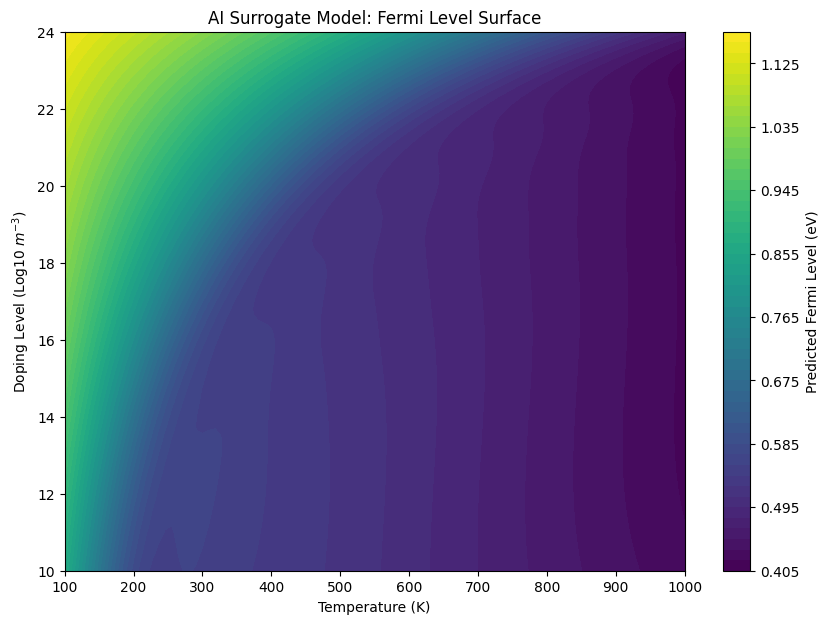


Model successfully saved to 'silicon_fermi_surrogate.pth'


In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Create a massive testing grid
# ==========================================
# 100x100 grid = 10,000 new test points
T_test = np.linspace(100, 1000, 100)
Nd_test_log = np.linspace(10, 24, 100)

# Create a meshgrid for plotting
T_grid, Nd_grid = np.meshgrid(T_test, Nd_test_log)

# Flatten the grid to feed it to the AI
T_flat = T_grid.flatten()
Nd_flat = Nd_grid.flatten()

# Combine into a single array: [10000 rows, 2 columns]
X_test_raw = np.column_stack((T_flat, Nd_flat))

# ==========================================
# 2. Scale the data (CRITICAL!)
# ==========================================
# We must use the exact same X_min and X_max from training!
X_test_scaled = (X_test_raw - X_min) / (X_max - X_min)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# ==========================================
# 3. Ask the AI for 10,000 predictions instantly
# ==========================================
# 'torch.no_grad()' tells PyTorch we are just testing, not training.
# It makes the prediction run 10x faster and saves memory.
with torch.no_grad():
    Ef_pred_flat = model(X_test_tensor).numpy()

# Reshape the flat predictions back into a 100x100 grid for the plot
Ef_pred_grid = Ef_pred_flat.reshape(100, 100)

# ==========================================
# 4. Plot the AI's "Brain"
# ==========================================
plt.figure(figsize=(10, 7))
contour = plt.contourf(T_grid, Nd_grid, Ef_pred_grid, levels=50, cmap='viridis')
plt.colorbar(contour, label='Predicted Fermi Level (eV)')

# Add the 0.56 eV Mid-gap line to show where it goes intrinsic
#plt.contour(T_grid, Nd_grid, Ef_pred_grid, levels=[0.56], colors='red', linestyles='dashed')

plt.title('AI Surrogate Model: Fermi Level Surface')
plt.xlabel('Temperature (K)')
plt.ylabel('Doping Level (Log10 $m^{-3}$)')
#plt.text(150, 11, "-- Red Dashed Line = Intrinsic Mid-gap", color='red', fontsize=10, backgroundcolor='white')
plt.show()

# ==========================================
# 5. Save the Model!
# ==========================================
# If you close Jupyter right now, the model's memory is wiped.
# This saves the trained weights to a file so you can load them later.
torch.save(model.state_dict(), "silicon_fermi_surrogate.pth")
print("\nModel successfully saved to 'silicon_fermi_surrogate.pth'")